[ torchvision.trasforms 서브모듈 ]
- pytorch에서 컴퓨터비전 이미지 처리를 위해서 제공하는 모듈
- 다양한 이미지 전처리 가능
- 기본 이미지 타임 PILImage 터입, ndarray 타입 사용
- 대부분이 PILImage 터입만 지원
- 버전 V1, V2이 존재하며 V2에 존재하지 않는 것들도 있음. 체크 후 사용!

In [38]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib

import torchvision.transforms as TF
import torch

<PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x400 at 0x1CE83E28FD0>


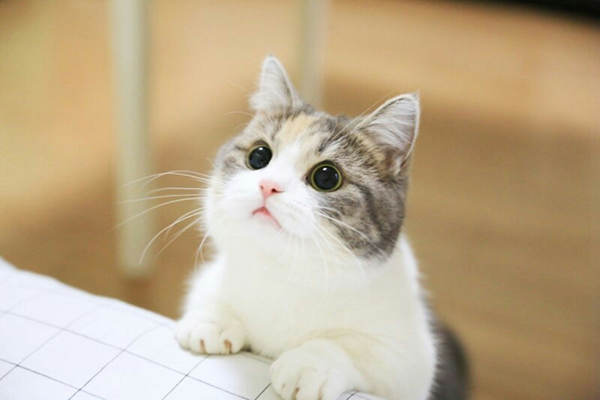

<function Tensor.type>

<function Tensor.type>

In [76]:
IMG_FILE = '../DAY06/animals//train/cat/cat (23).jpg'
img = Image.open(IMG_FILE)
print(img)
display(img)
cat = np.array(img)

# torch.tensor : PIL (파일은 변환 불가) => np => tensor
cat = torch.tensor(cat)
display(cat.type)

# torchvision.transforms : PLI => tensor
tf = TF.ToTensor()(img)
display(tf.type) 

In [ ]:
# [2] 이미지 픽셀 데이터 저장된 텐서
# 이미지 처리용 CNN Layer : 입력 이미지 구성 (C,H,W)
#                         Tensor 입력
# => ndarray ---> tensor
print(f'{cat.shape} [H, W, C]')
cat = cat.permute(2, 0, 1)
print(f'{cat.shape} [C, H, W]')

# => PIL ---> tensor
print(f'{tf.shape} [C, H, W]')

torch.Size([400, 600, 3]) [H, W, C]
torch.Size([3, 400, 600]) [H, W, C]
torch.Size([3, 400, 600]) [C, H, W]


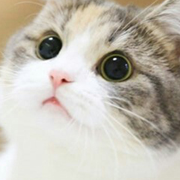

In [65]:
resize = TF.CenterCrop((180, 180))
resize(img)

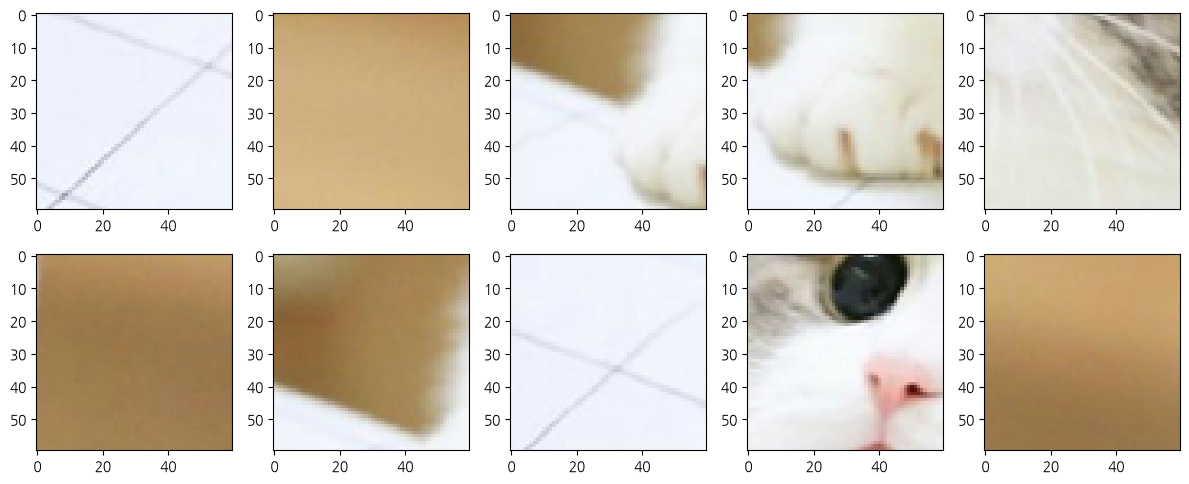

In [99]:
resultIMG = []
for _ in range(10):
    rcropTool = TF.RandomCrop((60,60))
    resultIMG.append(rcropTool(img))

def print_image(ncol, nrow, imgDatas):
    _, axes = plt.subplots(ncol, nrow, figsize=( 6*ncol, nrow ))
    axes = axes.flatten()
    for ax, imgData in zip(axes, imgDatas):
        ax.imshow(imgData)
    plt.tight_layout()
    plt.show()
print_image(2, 5, resultIMG)

In [78]:
# 이미지 회색 변환
grayTool = TF.Grayscale()
out_img = grayTool(img)

filename = IMG_FILE.split('/')[-1]
out_img.save(f'./rote_{filename}')

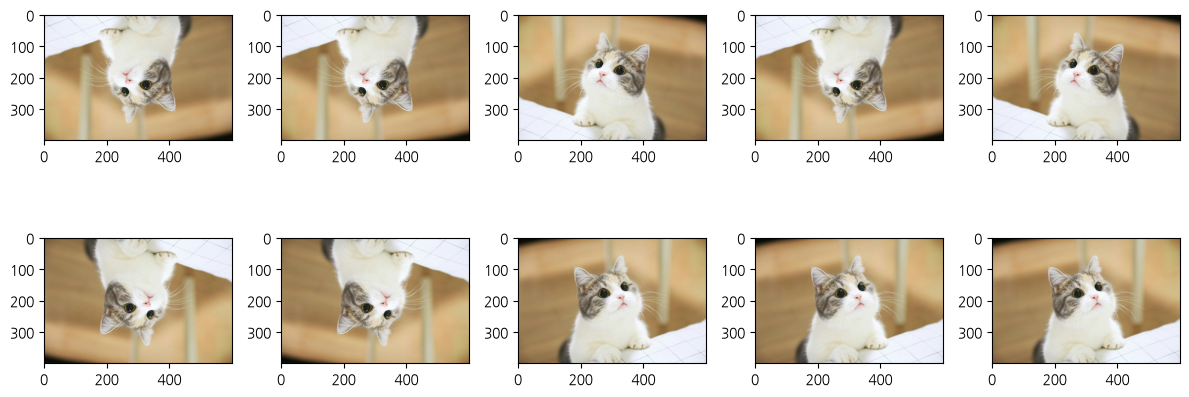

In [102]:
hFlipTool = TF.RandomHorizontalFlip()
vFlipTool = TF.RandomVerticalFlip()
resultIMG = [vFlipTool(hFlipTool(img)) for _ in range(10)]
print_image(2, 5, resultIMG)


In [114]:
# 전처리
resultIMG = TF.ToTensor()(TF.Resize((70, 70))(TF.CenterCrop((140,140))(TF.Grayscale()(img))))
print(f'{resultIMG.type} \n {resultIMG.shape}')

<built-in method type of Tensor object at 0x000001CE88208F50> 
 torch.Size([1, 70, 70])


In [ ]:
preprocessing = TF.Compose(
    TF.Grayscale(),
    TF.CenterCrop(140,140),
    TF.Resize(70, 70),
    TF.ToTensor(),
    TF.RandomHorizontalFlip(),
    TF.RandomVerticalFlip(),
)

IMG_DIR = '../DAY06/animals/train/cat'
OUT_DIR = './AUG'

import os
os.makedirs(OUT_DIR, exist_ok=True)

imglist = os.listdir(IMG_DIR)
for filename in imglist:
    img = Image.open(f'{IMG_DIR}/{filename}')
    out = preprocessing(img)
    out.save(f'{OUT_DIR}/{filename}')